# Markov Random Field (Undirected Graph) - Cleveland Heart Disease Dataset

An undirected probabilistic graphical model with a fixed, domain-knowledge-based 3-layer structure:
**Risk Factors -- Disease -- Symptoms**

- Parameterization via empirical unary and pairwise potentials (Laplace smoothing)
- Inference via Belief Propagation

## 1. Setup

In [1]:
!pip install pgmpy --quiet

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

from pgmpy.models import MarkovNetwork
from pgmpy.factors.discrete import DiscreteFactor
from pgmpy.inference import BeliefPropagation

print('MRF libraries imported successfully')

MRF libraries imported successfully


## 2. Data Loading and Discretization

In [3]:
df = pd.read_csv('heart_disease_cleaned.csv')
print(f'Loaded: {df.shape[0]} rows x {df.shape[1]} cols')
df.head(3)

Loaded: 303 rows x 14 cols


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1


In [4]:
df_disc = df.copy()

# Target: binarize num (0 = healthy, 1 = disease)
df_disc['num'] = (df_disc['num'] > 0).astype(int)

# Continuous -> ordinal bins
df_disc['age'] = pd.cut(df_disc['age'], bins=[0, 45, 60, float('inf')], labels=[0, 1, 2]).astype(int)
df_disc['trestbps'] = (df_disc['trestbps'] >= 130).astype(int)
df_disc['chol'] = pd.cut(df_disc['chol'], bins=[0, 199, 240, float('inf')], labels=[0, 1, 2]).astype(int)
df_disc['thalach'] = pd.cut(df_disc['thalach'], bins=[0, 119, 150, float('inf')], labels=[0, 1, 2]).astype(int)
df_disc['oldpeak'] = pd.cut(df_disc['oldpeak'], bins=[-0.001, 1.0, 2.0, float('inf')], labels=[0, 1, 2]).astype(int)

# Ordinal remapping
df_disc['cp'] = (df_disc['cp'] - 1).astype(int)
df_disc['slope'] = (df_disc['slope'] - 1).astype(int)
thal_map = {3: 0, 6: 1, 7: 2}
df_disc['thal'] = df_disc['thal'].astype(float).round().astype(int).map(thal_map)

# Already discrete
for col in ['ca', 'sex', 'fbs', 'restecg', 'exang']:
    df_disc[col] = df_disc[col].astype(float).round().astype(int)

nan_count = df_disc.isnull().sum().sum()
assert nan_count == 0, f'Found {nan_count} NaNs after discretization'
print('Discretization complete. Zero NaNs confirmed.')
print('\nValue ranges after discretization:')
print(df_disc.agg(['min', 'max']))

Discretization complete. Zero NaNs confirmed.

Value ranges after discretization:
     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
min    0    0   0         0     0    0        0        0      0        0   
max    2    1   3         1     2    1        2        2      1        2   

     slope  ca  thal  num  
min      0   0     0    0  
max      2   3     2    1  


In [5]:
df_disc.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,2,1,0,1,1,1,2,1,0,2,2,0,1,0
1,2,1,3,1,2,0,2,0,1,1,1,3,0,1
2,2,1,3,0,1,0,2,1,1,2,1,2,2,1
3,0,1,2,1,2,0,0,2,0,2,2,0,0,0
4,0,0,1,1,1,0,2,2,0,1,0,0,0,0


## 3. Undirected Graph Definition and Visualization

We keep the same domain structure as the BN, but make all links undirected.

In [6]:
RISK_FACTORS = ['age', 'sex', 'fbs', 'chol', 'trestbps']
DISEASE = ['num']
SYMPTOMS = ['cp', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'restecg']

edges = [(rf, 'num') for rf in RISK_FACTORS] + [('num', sym) for sym in SYMPTOMS]

mrf = MarkovNetwork()
mrf.add_nodes_from(RISK_FACTORS + DISEASE + SYMPTOMS)
mrf.add_edges_from(edges)

print('Edges defined:', len(edges))
print('Nodes:', sorted(mrf.nodes()))

Edges defined: 13
Nodes: ['age', 'ca', 'chol', 'cp', 'exang', 'fbs', 'num', 'oldpeak', 'restecg', 'sex', 'slope', 'thal', 'thalach', 'trestbps']


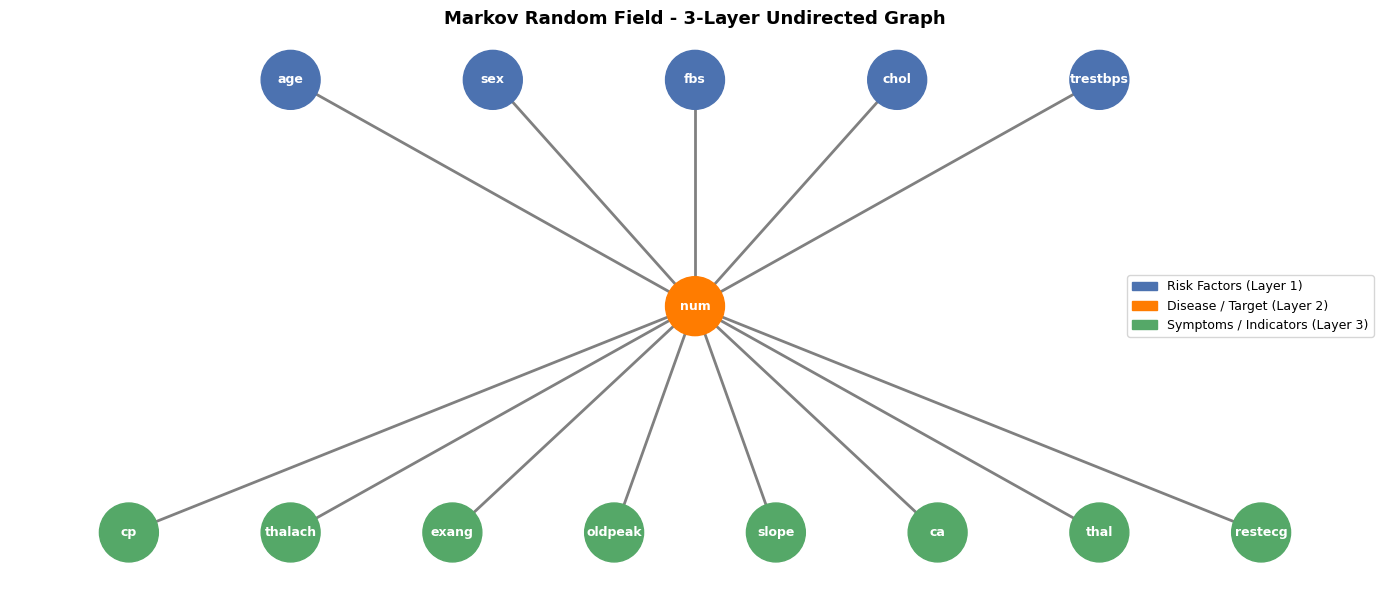

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))

G = nx.Graph()
G.add_nodes_from(RISK_FACTORS + DISEASE + SYMPTOMS)
G.add_edges_from(edges)

# 3-layer layout
pos = {}
n_rf = len(RISK_FACTORS)
for i, node in enumerate(RISK_FACTORS):
    pos[node] = ((i - (n_rf - 1) / 2) * 2.5, 2)
pos['num'] = (0, 0)
n_sym = len(SYMPTOMS)
for i, node in enumerate(SYMPTOMS):
    pos[node] = ((i - (n_sym - 1) / 2) * 2.0, -2)

node_colors = (['#4C72B0'] * len(RISK_FACTORS) + ['#FF7C00'] * len(DISEASE) + ['#55A868'] * len(SYMPTOMS))

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1800, ax=ax)
nx.draw_networkx_labels(G, pos, font_color='white', font_size=9, font_weight='bold', ax=ax)
nx.draw_networkx_edges(G, pos, width=2.0, edge_color='gray', ax=ax)

legend_handles = [
    mpatches.Patch(color='#4C72B0', label='Risk Factors (Layer 1)'),
    mpatches.Patch(color='#FF7C00', label='Disease / Target (Layer 2)'),
    mpatches.Patch(color='#55A868', label='Symptoms / Indicators (Layer 3)')
]
ax.legend(handles=legend_handles, loc='center right', fontsize=9)
ax.set_title('Markov Random Field - 3-Layer Undirected Graph', fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Factor Learning (Unary and Pairwise Potentials)

To parameterize the MRF, we estimate:
- Unary factors from node marginals
- Pairwise factors from edge-wise joint frequencies
Both with Laplace smoothing to avoid zero potentials.

In [8]:
state_names = {
    'age': [0, 1, 2],
    'sex': [0, 1],
    'fbs': [0, 1],
    'chol': [0, 1, 2],
    'trestbps': [0, 1],
    'num': [0, 1],
    'cp': [0, 1, 2, 3],
    'thalach': [0, 1, 2],
    'exang': [0, 1],
    'oldpeak': [0, 1, 2],
    'slope': [0, 1, 2],
    'ca': [0, 1, 2, 3],
    'thal': [0, 1, 2],
    'restecg': [0, 1, 2]
}

def unary_potential(data, var, states, alpha=1.0):
    counts = data[var].value_counts().reindex(states, fill_value=0).astype(float).values
    probs = (counts + alpha) / (counts.sum() + alpha * len(states))
    return probs

def pairwise_potential(data, u, v, states_u, states_v, alpha=1.0):
    table = pd.crosstab(data[u], data[v], dropna=False)
    table = table.reindex(index=states_u, columns=states_v, fill_value=0).astype(float)
    joint = (table.values + alpha)
    joint = joint / joint.sum()
    return joint

print('Potential helper functions ready.')

Potential helper functions ready.


In [9]:
# Add unary factors for each node
all_nodes = RISK_FACTORS + DISEASE + SYMPTOMS
for node in all_nodes:
    states = state_names[node]
    phi_u = unary_potential(df_disc, node, states, alpha=1.0)
    factor_u = DiscreteFactor(variables=[node], cardinality=[len(states)], values=phi_u, state_names={node: states})
    mrf.add_factors(factor_u)

# Add pairwise factors for each undirected edge
for u, v in edges:
    states_u = state_names[u]
    states_v = state_names[v]
    phi_uv = pairwise_potential(df_disc, u, v, states_u, states_v, alpha=1.0)
    factor_uv = DiscreteFactor(
        variables=[u, v],
        cardinality=[len(states_u), len(states_v)],
        values=phi_uv,
        state_names={u: states_u, v: states_v}
    )
    mrf.add_factors(factor_uv)

valid = mrf.check_model()
print(f'MRF valid (check_model): {valid}')
print(f'Factors attached: {len(mrf.factors)}')

MRF valid (check_model): True
Factors attached: 27


## 5. Inference with Belief Propagation

In [10]:
bp = BeliefPropagation(mrf)

# Q1: Prior disease prevalence P(num)
q1 = bp.query(variables=['num'])
print('Q1 - Prior P(num) (no evidence):')
print(q1)

# Q2: Forward inference
q2 = bp.query(variables=['num'], evidence={'age': 2, 'sex': 1, 'chol': 2})
print('\nQ2 - P(num | age=2 [senior], sex=1 [male], chol=2 [high]):')
print(q2)

# Q3: Backward inference
q3 = bp.query(variables=['num'], evidence={'exang': 1, 'oldpeak': 2, 'ca': 2})
print('\nQ3 - P(num | exang=1 [angina], oldpeak=2 [high ST depression], ca=2 [2 vessels]):')
print(q3)

# Q4: Posterior symptom distribution
q4_healthy = bp.query(variables=['thalach'], evidence={'num': 0})
q4_disease = bp.query(variables=['thalach'], evidence={'num': 1})
print('\nQ4 - P(thalach | num=0 [healthy]):')
print(q4_healthy)
print('\nQ4 - P(thalach | num=1 [disease]):')
print(q4_disease)

Q1 - Prior P(num) (no evidence):
+--------+------------+
| num    |   phi(num) |
+========+============+
| num(0) |     0.9623 |
+--------+------------+
| num(1) |     0.0377 |
+--------+------------+

Q2 - P(num | age=2 [senior], sex=1 [male], chol=2 [high]):
+--------+------------+
| num    |   phi(num) |
+========+============+
| num(0) |     0.9250 |
+--------+------------+
| num(1) |     0.0750 |
+--------+------------+

Q3 - P(num | exang=1 [angina], oldpeak=2 [high ST depression], ca=2 [2 vessels]):
+--------+------------+
| num    |   phi(num) |
+========+============+
| num(0) |     0.0698 |
+--------+------------+
| num(1) |     0.9302 |
+--------+------------+

Q4 - P(thalach | num=0 [healthy]):
+------------+----------------+
| thalach    |   phi(thalach) |
+============+================+
| thalach(0) |         0.0116 |
+------------+----------------+
| thalach(1) |         0.1707 |
+------------+----------------+
| thalach(2) |         0.8177 |
+------------+--------------

In [11]:
# Verify normalization
for name, q in [('Q1', q1), ('Q2', q2), ('Q3', q3), ('Q4-healthy', q4_healthy), ('Q4-disease', q4_disease)]:
    total = q.values.sum()
    ok = abs(total - 1.0) < 1e-6
    print(f"{name}: sum = {total:.6f}  {'OK' if ok else 'FAIL'}")

Q1: sum = 1.000000  OK
Q2: sum = 1.000000  OK
Q3: sum = 1.000000  OK
Q4-healthy: sum = 1.000000  OK
Q4-disease: sum = 1.000000  OK


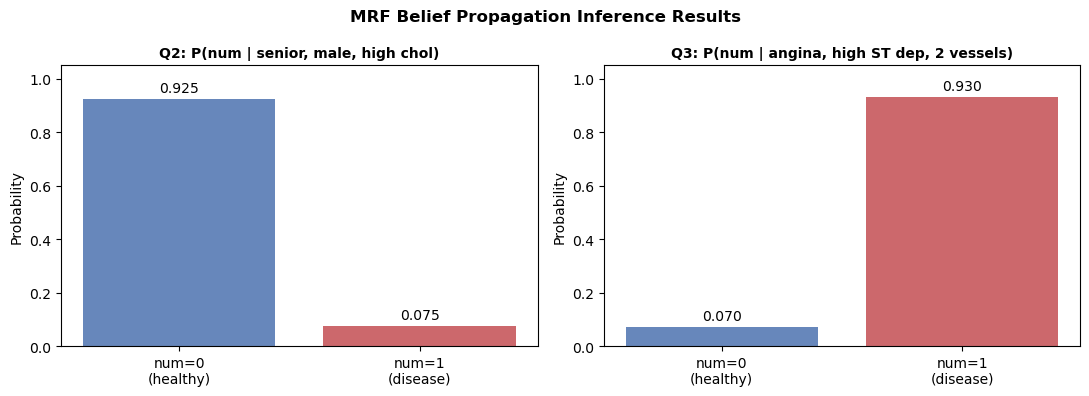

In [12]:
# Visualize Q2 and Q3
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, q, title in zip(
    axes,
    [q2, q3],
    ['Q2: P(num | senior, male, high chol)', 'Q3: P(num | angina, high ST dep, 2 vessels)']
):
    bars = ax.bar(['num=0\n(healthy)', 'num=1\n(disease)'], q.values, color=['#4C72B0', '#C44E52'], alpha=0.85)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Probability', fontsize=10)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=10)

plt.suptitle('MRF Belief Propagation Inference Results', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

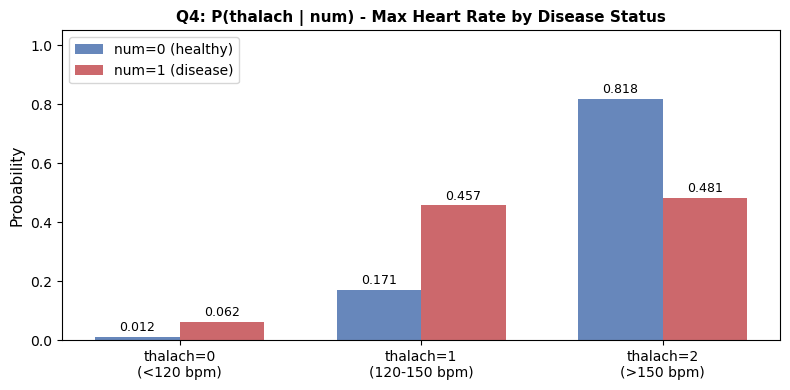

In [13]:
# Visualize Q4
labels = ['thalach=0\n(<120 bpm)', 'thalach=1\n(120-150 bpm)', 'thalach=2\n(>150 bpm)']
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
bars_h = ax.bar(x - width / 2, q4_healthy.values, width, label='num=0 (healthy)', color='#4C72B0', alpha=0.85)
bars_d = ax.bar(x + width / 2, q4_disease.values, width, label='num=1 (disease)', color='#C44E52', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Probability', fontsize=11)
ax.set_title('Q4: P(thalach | num) - Max Heart Rate by Disease Status', fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
ax.bar_label(bars_h, fmt='%.3f', padding=2, fontsize=9)
ax.bar_label(bars_d, fmt='%.3f', padding=2, fontsize=9)
plt.tight_layout()
plt.show()